# Pytorch Workflows

Pytorch end-to-end workflow lab from the Pytorch course on YT.

## What are we covering

1. Getting data ready
2. Build models
3. Fit the model on training data
4. making preditions and evaluating model on test data
5. save and load the model
6. putting it all together

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

## Preparing and loading data

Data can be almost anything!

**Main steps of Machine and Deep Learning**

1. Get data ready for numerical representation
2. build a model to understand and learn represtations of the data

Lets build a linear regression model.

In [2]:
# Create known parameters

weight = 0.7
bias = 0.3

# Create a perceptron
start =0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)

y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

### Splitting data into training and test datasets

Very important in ML and DL

**Framework**:
- Training set: ~ 60-80% (Always use!)
- Validation set: ~ 10-20% ( Often but not always)
- Testing set: ~ 10-20% (Always)

Below we will *not* be using

In [4]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### How to visualize data

> "Visualize, visualize, visualize!!!"

In [6]:
def plot_predictions(train_data=X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

  # Plot test data in green
  plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

  # Are there predictions
  if predictions is not None:
    plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

  plt.legend(prop={'size': 14});


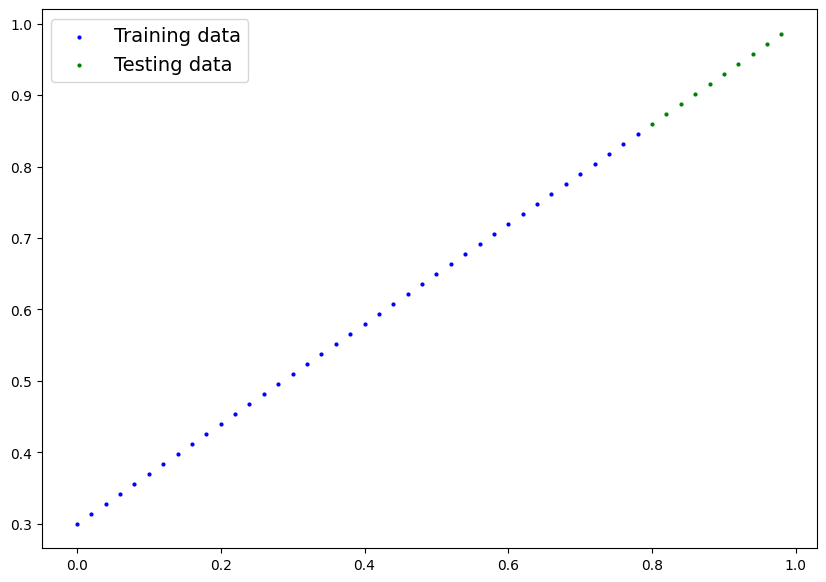

In [6]:
plot_predictions();

## Building a model

Linear regression model.

> **Y = a + bX**

In [7]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  # Forward to forward propagate through the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias

### Essentials for building models

- torch.nn: contains all building blocks for building a model
- torch.nn.Parameter: what the model needs to learn, compute, and back propagate through
- torch.nn.Module: base class for all nueral networks
- torch.optim: Contains various optimization algorithms(i use AdamW)
- def forward(): this method defines what happens in the forward computation.

### Checking the contents of the pytorch model.

How can we look inside a model and understand what is inside the model?

In [8]:
# create a random seed
torch.manual_seed(42)

#Initalize model
model_0 = LinearRegressionModel()

#Check out parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Predictions using `torch.inference_mode()`

To evaluate our model's capabilites, we need to check it on out `y_test` dataset.

We will finally use the `forward` function to forward propagate through the model.

In [10]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [11]:
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [12]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

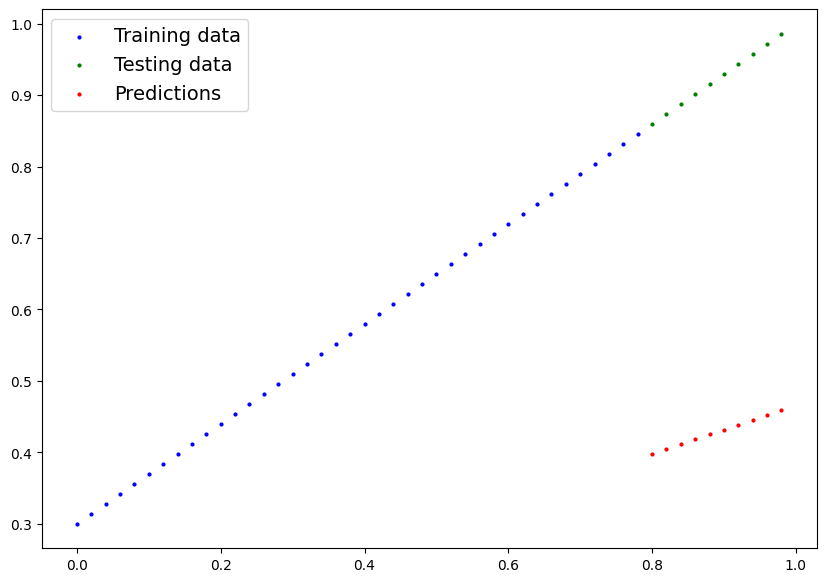

In [13]:
plot_predictions(predictions=y_preds)

## Training a model

While training the model our objective is to match our predictions to match the y_test data.

There are 2 more things we need to define before training.
- **Loss function**: Measures how off our model is. We will use either MAE for regression and binary cross entropy for binary classification problems.

- **Optimizer**: *How* to update its internal paramters to better lower the loss. Many optimizers but we will use `torch.optim.SGD()` or `torch.optim.Adam()`



### How to define a loss function and optimzer

we will use `torch.optim.SGD(params, lr)` to define our optimizer. This is going to define our gradient decent.

- `params` is the target model's parameters that we will optimize during training.
- `lr` is out learning rate that defines how frequently we want to update our model. We can either do large or small updates but if we do too big updates or too small updates then the optimizer will fail or will take too long to train.

In [14]:
loss_fn = nn.L1Loss()

# Optimizer will now be defined within the training loop after model re-initialization.

### Training loop

1. Forward pass: Forward propagate through the model
2. Calculate loss of the model: `loss = loss_fn(y_pred, y_train_)`
3. Zero Gradients: The model's outputs are compared to the truth and eval to see how wrong they are. `optimzer.zero_grad()`
4. Backprop: Computes gradient decent for all the weights or parameters. `loss.backward()`
5. Update the optimizer. `optimizer.step()`

### Testing loop

1. Forward pass: Go through all testing data once
2. Calculate the loss: Model's outputs are compared to ground truth
3. Calculate evaluation metrics: Calculate ealuation metrics.

In [15]:
torch.manual_seed(42)

# Re-initialize the model to start with fresh random parameters
model_0 = LinearRegressionModel()

# Re-initialize the optimizer with the new model's parameters
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.001) # Increased learning rate for faster convergence

epochs = 5000 # Increased epochs to observe more gradual learning

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  ########### Training ###########

  # Put model in training mode
  model_0.train()

  # 1. Forward pass on training data using forward method inside
  y_pred = model_0(X_train)

  # 2. Calculate loss
  # Ensure y_train is float for loss calculation
  loss = loss_fn(y_pred, y_train.type(torch.float))

  # 3. Zero grad of the optimzer
  optimizer.zero_grad()

  # 4. Loss backwards
  loss.backward()

  # 5. Progress the optimizer
  optimizer.step()

  ########### Testing ###########

  model_0.eval()

  with torch.inference_mode():
    # 1. Forward pass on test data
    test_pred = model_0(X_test)

    # 2. Calculate the loss on test data
    test_loss = loss_fn(test_pred, y_test.type(torch.float))

    # Print out the results after 100 epochs
    if epoch % 100 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")
      # Print model parameters to observe changes
      print(f"Model parameters at Epoch {epoch}: {model_0.state_dict()}")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.4931890368461609 
Model parameters at Epoch 0: OrderedDict({'weights': tensor([0.3371]), 'bias': tensor([0.1298])})
Epoch: 100 | MAE Train Loss: 0.19767141342163086 | MAE Test Loss: 0.35847947001457214 
Model parameters at Epoch 100: OrderedDict({'weights': tensor([0.3761]), 'bias': tensor([0.2298])})
Epoch: 200 | MAE Train Loss: 0.08973254263401031 | MAE Test Loss: 0.22795839607715607 
Model parameters at Epoch 200: OrderedDict({'weights': tensor([0.4150]), 'bias': tensor([0.3257])})
Epoch: 300 | MAE Train Loss: 0.05357731133699417 | MAE Test Loss: 0.15086300671100616 
Model parameters at Epoch 300: OrderedDict({'weights': tensor([0.4485]), 'bias': tensor([0.3730])})
Epoch: 400 | MAE Train Loss: 0.04549176245927811 | MAE Test Loss: 0.11657620966434479 
Model parameters at Epoch 400: OrderedDict({'weights': tensor([0.4730]), 'bias': tensor([0.3855])})
Epoch: 500 | MAE Train Loss: 0.04160415381193161 | MAE Test Loss: 0.10

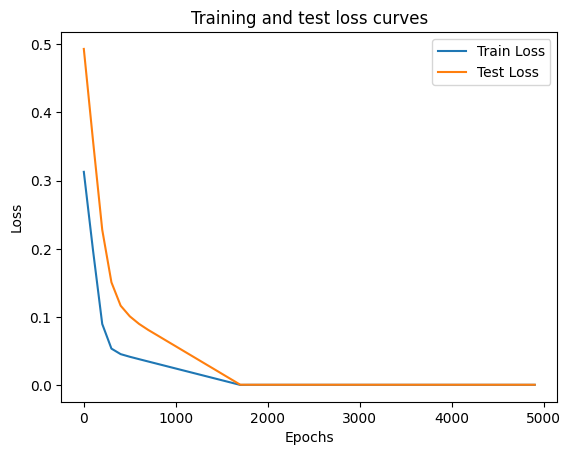

In [16]:
plt.plot(epoch_count, train_loss_values, label='Train Loss')
plt.plot(epoch_count, test_loss_values, label='Test Loss')
plt.title('Training and test loss curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend();

In [17]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.8593],
        [0.8733],
        [0.8873],
        [0.9013],
        [0.9152],
        [0.9292],
        [0.9432],
        [0.9572],
        [0.9712],
        [0.9852]])

#### **WE DID IT!!!**

After 5000 epochs of training, the red line is now perfectly matched with our testing data!!

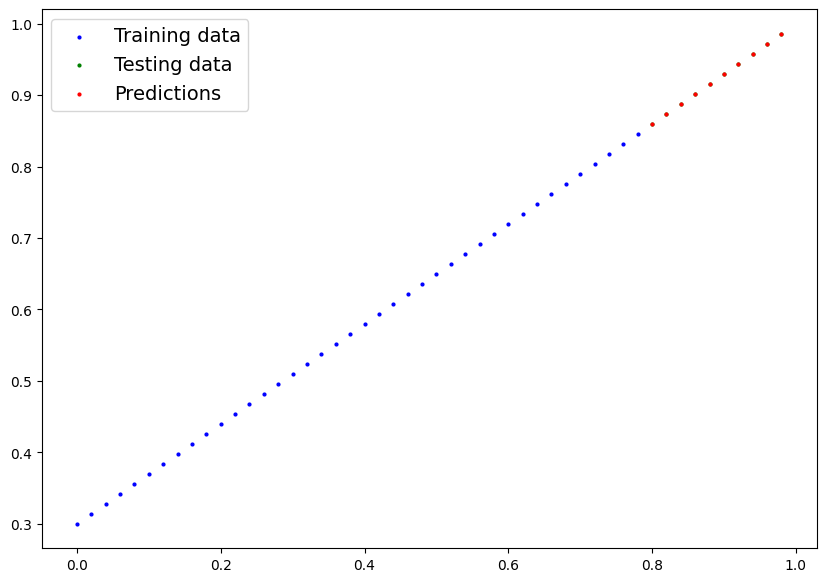

In [18]:
plot_predictions(predictions=y_preds)

## Saving a model

3 main methods of saving and loading models

1. `torch.save()`: Allows you to save pytorch object
2. `torch.load()`: Load a saved pytorch object
3. `torch.nn.Module.load_state_dict()`: allows load of model's saved state dict.

In [21]:
# Save our pytorch model

from pathlib import Path

MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = '1st_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/1st_pytorch_workflow_model_0.pth


## Loading a model

In [22]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6994])), ('bias', tensor([0.2998]))])

In [23]:
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [24]:
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8593],
        [0.8733],
        [0.8873],
        [0.9013],
        [0.9152],
        [0.9292],
        [0.9432],
        [0.9572],
        [0.9712],
        [0.9852]])

In [25]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Putting it all together

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.11.0+cpu'

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


### Data

In [4]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [5]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

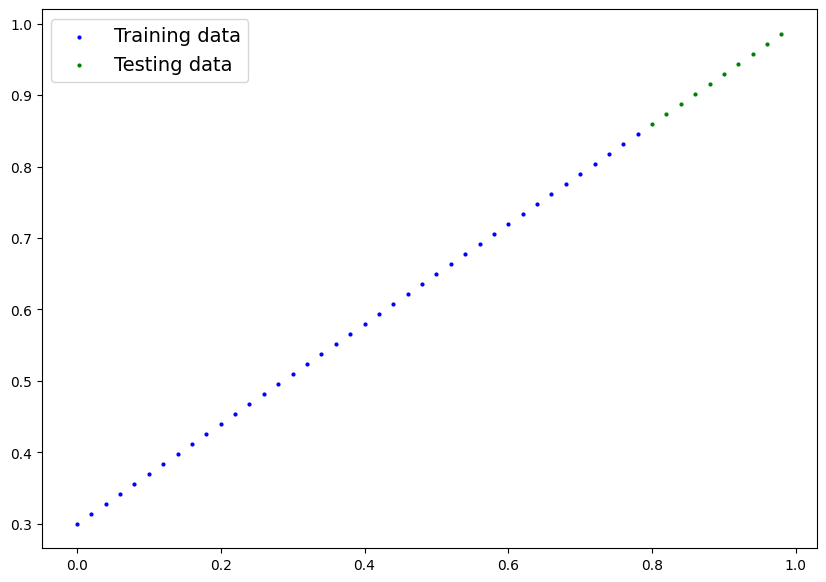

In [7]:
# Plot data
plot_predictions(X_train, y_train, X_test, y_test)

### Building a Pytorch Linear Model

In [13]:
class LinearModel2(nn.Module):
  def __init__(self):
    super().__init__()
    # use nn.Linear for creating model parameters
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)
  def forward(self, x) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearModel2()
model_1, model_1.state_dict()

(LinearModel2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

### Training our model

**Remember!!**:
- Loss function
- Optimizer
- Training loop
- Testing loop


In [16]:
# Define loss function
loss_fn = nn.L1Loss()

# Define optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                           lr = 0.01)



In [18]:
# Writing out training loop
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
  model_1.train()

  # Forward Pass
  y_preds = model_1(X_train)

  # Calculate the loss
  loss = loss_fn(y_preds, y_train)

  # Zero grad
  optimizer.zero_grad()

  # Backpropagation
  loss.backward()

  # Gradient step
  optimizer.step()

  ### Testing ###
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)

    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f'Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}')

Epoch: 0 | Loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399680495262146 | Test loss: 0.4392663538455963
Epoch: 20 | Loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954827964305878 | Test loss: 0.16984674334526062
Epoch: 40 | Loss: 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch: 50 | Loss: 0.023886386305093765 | Test loss: 0.04784906655550003
Epoch: 60 | Loss: 0.0199567973613739 | Test loss: 0.04580312222242355
Epoch: 70 | Loss: 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch: 80 | Loss: 0.013089170679450035 | Test loss: 0.029944902285933495
Epoch: 90 | Loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 110 | Loss: 0.002787243574857712 | Test loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 130 | Loss: 0.0012645035749301314 | Test loss: 0.01380180753767

In [21]:
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

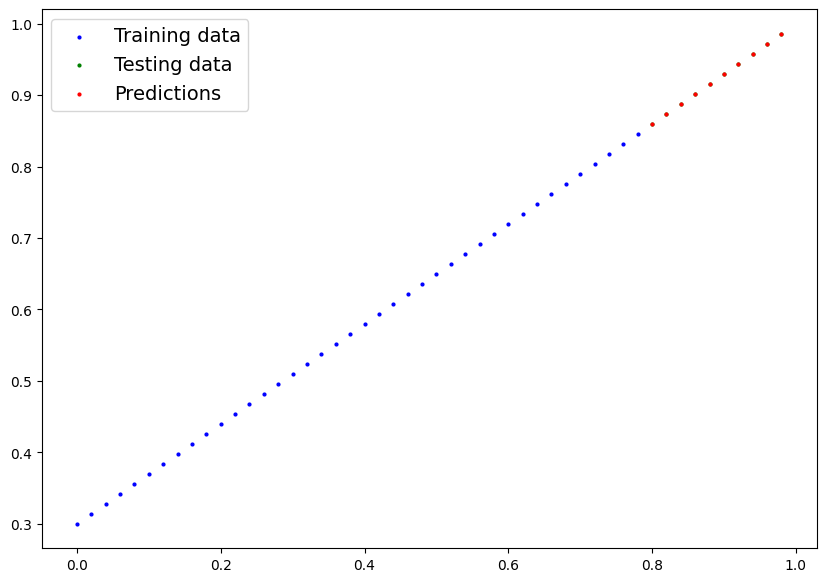

In [22]:
plot_predictions(predictions=y_preds)

## Saving and Loading a Model

In [23]:
from pathlib import Path

MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'model_1.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/model_1.pth


In [25]:
# Load a Pytorch model

# Create new instance of linear regression model 2
loaded_model_1 = LinearModel2()

# Load state dict of model_1
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [26]:
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])